# NIFTY Options IV Surface Reconstruction

## Objective

The task is to reconstruct missing implied volatility (IV) values in a NIFTY options dataset.

The dataset contains:

- Timestamp
- Underlying Price
- Call Option IVs
- Put Option IVs

Several IV entries are missing and must be estimated.

The challenge is to leverage both:

1. Cross-sectional information (relationship between strikes at the same timestamp)
2. Temporal information (historical behaviour of each strike)

to reconstruct the missing values while avoiding look-ahead bias.

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("dataset.csv")

print(df.shape)
df.head()

(975, 30)


,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,NIFTY27JAN2626000CE,NIFTY27JAN2626100CE,NIFTY27JAN2626200CE,NIFTY27JAN2626300CE,NIFTY27JAN2626400CE,NIFTY27JAN2626500CE,NIFTY27JAN2623800PE,NIFTY27JAN2623900PE,NIFTY27JAN2624000PE,NIFTY27JAN2624100PE,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,07-01-2026 09:15,26111.65,0.12662,0.12330,0.11741,NaN,0.11005,0.10576,NaN,0.09724,0.09570,0.09397,0.09187,0.09041,0.08908,0.08795,0.17840,0.17237,0.16928,NaN,0.15760,0.15240,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,0.09837,0.09619,0.09413,0.09236,0.09057,0.08925,0.17962,0.17477,NaN,0.16534,NaN,0.15420,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,0.08996,0.08861,0.08697,0.08627,0.08541,NaN,0.18010,0.17574,0.17154,0.16567,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN
3,07-01-2026 09:30,26128.95,0.10860,0.10842,0.11150,0.12248,0.10715,0.11098,0.10345,NaN,0.09864,0.09511,0.09304,0.09123,NaN,0.08843,0.18174,NaN,0.17206,0.16502,0.15755,NaN,0.14691,0.14209,0.13721,0.13184,0.12722,0.12252,0.11729,0.11200
4,07-01-2026 09:35,26131.90,0.10462,0.10538,0.12459,0.12051,0.11225,0.11294,0.10544,NaN,0.09896,NaN,0.09412,0.09136,0.09014,0.08885,0.18193,NaN,0.17226,0.16522,0.15924,0.15334,0.14784,0.14230,NaN,0.13219,0.12733,0.12295,0.11707,NaN


In [5]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 975 entries, 0 to 974
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datetime             975 non-null    object 
 1   underlying_price     975 non-null    float64
 2   NIFTY27JAN2625200CE  781 non-null    float64
 3   NIFTY27JAN2625300CE  791 non-null    float64
 4   NIFTY27JAN2625400CE  773 non-null    float64
 5   NIFTY27JAN2625500CE  794 non-null    float64
 6   NIFTY27JAN2625600CE  795 non-null    float64
 7   NIFTY27JAN2625700CE  774 non-null    float64
 8   NIFTY27JAN2625800CE  765 non-null    float64
 9   NIFTY27JAN2625900CE  793 non-null    float64
 10  NIFTY27JAN2626000CE  794 non-null    float64
 11  NIFTY27JAN2626100CE  792 non-null    float64
 12  NIFTY27JAN2626200CE  766 non-null    float64
 13  NIFTY27JAN2626300CE  788 non-null    float64
 14  NIFTY27JAN2626400CE  762 non-null    float64
 15  NIFTY27JAN2626500CE  791 non-null    flo

,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,NIFTY27JAN2626000CE,NIFTY27JAN2626100CE,NIFTY27JAN2626200CE,NIFTY27JAN2626300CE,NIFTY27JAN2626400CE,NIFTY27JAN2626500CE,NIFTY27JAN2623800PE,NIFTY27JAN2623900PE,NIFTY27JAN2624000PE,NIFTY27JAN2624100PE,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
count,975.000000,781.000000,791.000000,773.000000,794.000000,795.000000,774.000000,765.000000,793.000000,794.000000,792.000000,766.000000,788.000000,762.000000,791.000000,772.000000,774.000000,766.000000,799.000000,758.000000,786.000000,773.000000,780.000000,777.000000,800.000000,766.000000,780.000000,780.000000,770.000000
mean,25564.155846,0.140259,0.138818,0.138240,0.142228,0.146016,0.152041,0.160795,0.166556,0.170306,0.184265,0.189361,0.195148,0.195159,0.218350,0.274608,0.267886,0.245142,0.244990,0.230603,0.222443,0.207041,0.191752,0.179123,0.166007,0.154250,0.141069,0.136577,0.126154
std,317.642518,0.068745,0.075571,0.090462,0.113038,0.141846,0.170909,0.198059,0.222128,0.228303,0.264587,0.299639,0.282702,0.275301,0.343940,0.288311,0.322412,0.287086,0.289143,0.266993,0.249447,0.222475,0.190352,0.165855,0.135587,0.111492,0.069741,0.071401,0.052776
min,24940.700000,0.016800,0.063170,0.074030,0.080590,0.081800,0.084060,0.085290,0.086000,0.084500,0.083860,0.083680,0.082690,0.082620,0.082220,0.171050,0.164420,0.162330,0.153920,0.149040,0.142520,0.134770,0.127890,0.116180,0.107260,0.101750,0.096340,0.089750,0.081910
25%,25266.850000,0.111710,0.110250,0.107390,0.105467,0.103865,0.102455,0.100830,0.099050,0.097935,0.096425,0.096592,0.097627,0.099145,0.101725,0.184890,0.178192,0.174255,0.168145,0.161523,0.155110,0.148590,0.142550,0.136040,0.130223,0.125075,0.119525,0.114673,0.109355
50%,25624.200000,0.122760,0.118660,0.114480,0.112460,0.109560,0.107620,0.106660,0.106850,0.107955,0.108015,0.107245,0.111270,0.114510,0.117300,0.196910,0.191870,0.186355,0.180250,0.171725,0.164835,0.157020,0.149170,0.141580,0.135060,0.128905,0.123640,0.118800,0.113695
75%,25768.200000,0.135670,0.128930,0.124020,0.121012,0.118900,0.117575,0.120410,0.125320,0.135595,0.141213,0.150867,0.159550,0.167310,0.176390,0.224483,0.213778,0.203095,0.193290,0.183098,0.174737,0.164270,0.156512,0.148150,0.140690,0.134568,0.128752,0.123983,0.118760
max,26183.800000,0.548960,0.577860,0.731570,1.139080,1.532590,1.916340,2.292520,2.662460,3.027050,2.655700,3.742590,2.506440,2.380210,3.690760,3.172010,5.384760,4.974530,4.593390,4.211720,3.829270,3.445750,3.060780,2.673900,2.284440,1.891510,0.755340,1.088710,0.592490


In [6]:
missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": 100 * df.isna().sum() / len(df)
})

missing = missing[missing["Missing Count"] > 0]

missing.sort_values(
    "Missing %",
    ascending=False
)

,Missing Count,Missing %
NIFTY27JAN2624200PE,217,22.256410
NIFTY27JAN2626400CE,213,21.846154
NIFTY27JAN2625800CE,210,21.538462
NIFTY27JAN2626200CE,209,21.435897
NIFTY27JAN2624800PE,209,21.435897
NIFTY27JAN2624000PE,209,21.435897
NIFTY27JAN2625100PE,205,21.025641
NIFTY27JAN2623800PE,203,20.820513
NIFTY27JAN2625400CE,202,20.717949
NIFTY27JAN2624400PE,202,20.717949


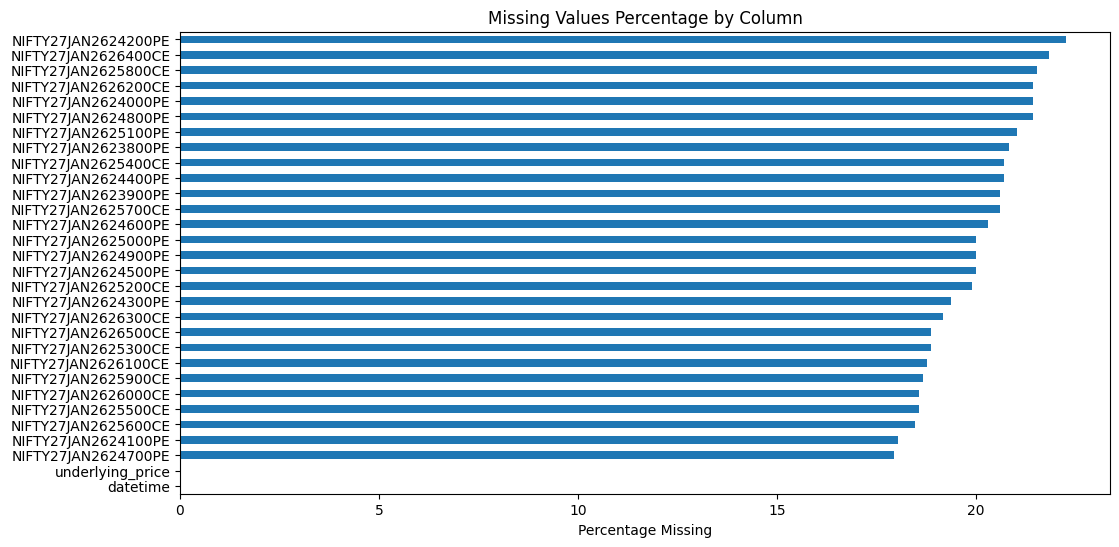

In [7]:
plt.figure(figsize=(12,6))

(
    100 * df.isna().sum() / len(df)
).sort_values().plot(
    kind="barh"
)

plt.title("Missing Values Percentage by Column")
plt.xlabel("Percentage Missing")

plt.show()

In [8]:
iv_cols = [
    c for c in df.columns
    if c not in ["datetime", "underlying_price"]
]

ce_cols = [c for c in iv_cols if c.endswith("CE")]
pe_cols = [c for c in iv_cols if c.endswith("PE")]

print("Total IV Columns :", len(iv_cols))
print("Call Columns     :", len(ce_cols))
print("Put Columns      :", len(pe_cols))

Total IV Columns : 28
Call Columns     : 14
Put Columns      : 14


In [9]:
def strike_from_col(col):
    return int(col[12:-2])

In [10]:
sample_row = 300

surface = []

for col in ce_cols:
    value = df.loc[sample_row, col]

    if pd.notna(value):
        surface.append(
            (
                strike_from_col(col),
                value
            )
        )

surface = pd.DataFrame(
    surface,
    columns=["Strike", "IV"]
)

surface.head()

,Strike,IV
0,25200,0.10138
1,25300,0.10057
2,25400,0.10156
3,25700,0.09894
4,26000,0.09738


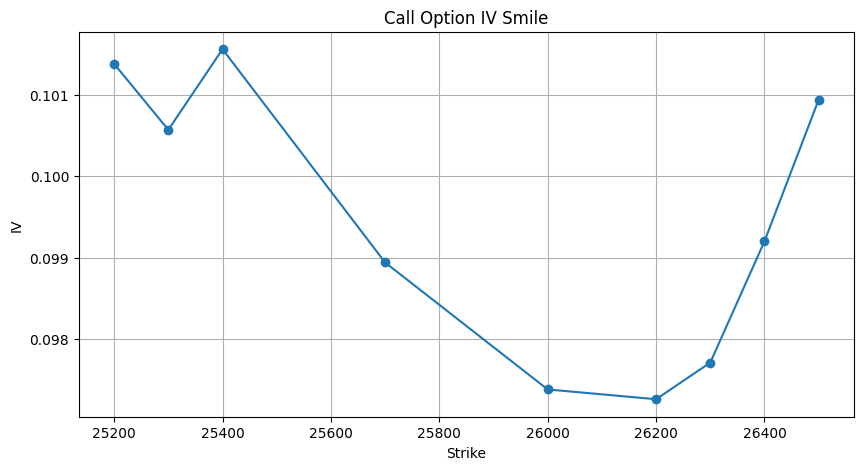

In [11]:
plt.figure(figsize=(10,5))

plt.plot(
    surface["Strike"],
    surface["IV"],
    marker="o"
)

plt.title("Call Option IV Smile")
plt.xlabel("Strike")
plt.ylabel("IV")

plt.grid(True)

plt.show()

In [12]:
sample_row = 300

surface_put = []

for col in pe_cols:
    value = df.loc[sample_row, col]

    if pd.notna(value):
        surface_put.append(
            (
                strike_from_col(col),
                value
            )
        )

surface_put = pd.DataFrame(
    surface_put,
    columns=["Strike", "IV"]
)

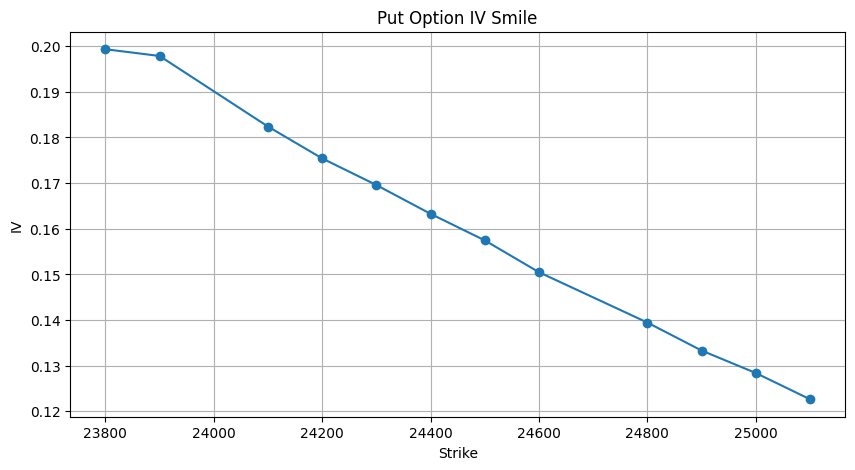

In [13]:
plt.figure(figsize=(10,5))

plt.plot(
    surface_put["Strike"],
    surface_put["IV"],
    marker="o"
)

plt.title("Put Option IV Smile")
plt.xlabel("Strike")
plt.ylabel("IV")

plt.grid(True)

plt.show()

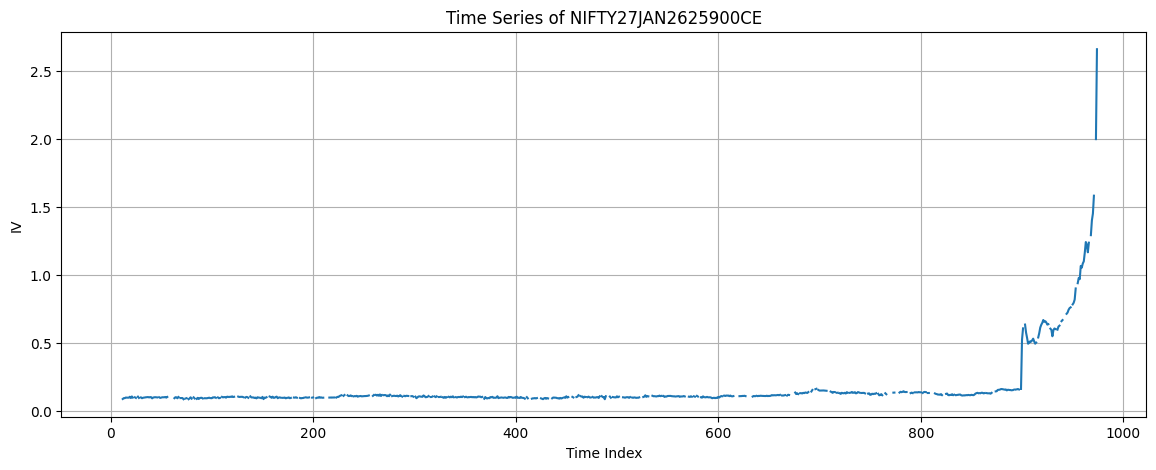

In [14]:
mid_call = ce_cols[len(ce_cols)//2]

plt.figure(figsize=(14,5))

plt.plot(df[mid_call])

plt.title(f"Time Series of {mid_call}")
plt.xlabel("Time Index")
plt.ylabel("IV")

plt.grid(True)

plt.show()


In [15]:
corr = df[ce_cols].corr()

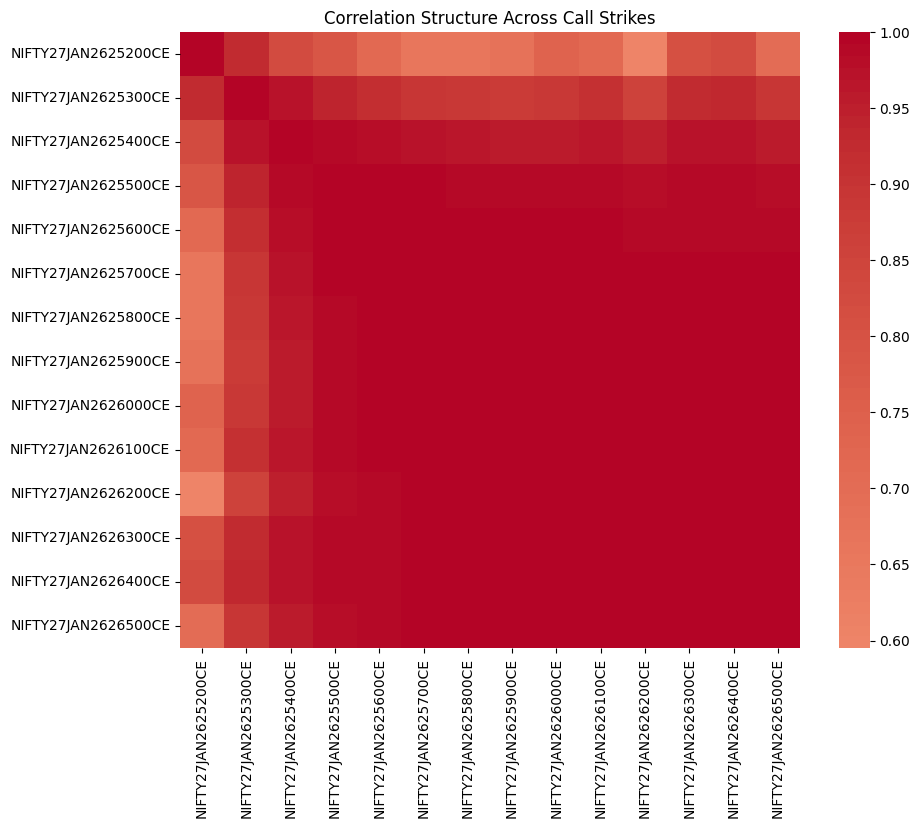

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Structure Across Call Strikes")

plt.show()

## Key Observations

1. Adjacent strikes exhibit strong correlation.

2. The implied volatility smile is smooth and locally continuous.

3. Missing values are scattered across strikes rather than entire timestamps.

4. Individual strike IVs evolve gradually through time.

These observations motivate a hybrid approach that combines:

- Cross-sectional smile estimation.
- Historical residual correction.

In [17]:
# ---------- Hyperparameters ----------
ALPHA_FAST = 0.30
ALPHA_SLOW = 0.05
W_FAST     = 0.60
BASE_CAP   = 0.015
CAP_FRAC   = 0.10
MIN_CAP    = 0.005

DATASET_PATH    = "dataset.csv"
SUBMISSION_PATH = "submission.csv"
SEP = "||"

# ---------- Load ----------
df = pd.read_csv(DATASET_PATH)
iv_cols = [c for c in df.columns if c not in ("datetime", "underlying_price")]
ce_cols = [c for c in iv_cols if c.endswith("CE")]
pe_cols = [c for c in iv_cols if c.endswith("PE")]
print(f"Loaded: {len(df)} rows, {len(iv_cols)} IV cols ({len(ce_cols)} CE, {len(pe_cols)} PE)")
print(f"Missing cells to fill: {df[iv_cols].isna().sum().sum()}")


# ---------- Cross-sectional smile prediction ----------
def cs_predict(row, col, group, is_ce):
    k0 = int(col[12:-2])
    obs = sorted(
        [(int(c[12:-2]), float(row[c])) for c in group
         if c != col and pd.notna(row[c]) and float(row[c]) > 0],
        key=lambda x: x[0]
    )
    if len(obs) < 2:
        return np.nan

    bl = sorted([(k, v) for k, v in obs if k < k0], key=lambda x: -x[0])
    ab = sorted([(k, v) for k, v in obs if k > k0], key=lambda x:  x[0])

    if bl and ab:
        pts = sorted(bl[:4] + ab[:4], key=lambda x: x[0])
        sk = np.array([p[0] for p in pts])
        sv = np.array([p[1] for p in pts])
        try:
            dists = np.abs(sk - k0).astype(float)
            dists[dists < 50] = 50
            weights = 1.0 / dists
            cf = np.polyfit(sk, sv, min(2, len(sk) - 1), w=weights)
            pred = float(np.polyval(cf, k0))
            local_min = min(sv[np.argmin(np.abs(sk - k0))], sv.min())
            local_max = max(sv[np.argmax(np.abs(sk - k0))], sv.max())
            if pred < local_min * 0.5 or pred > local_max * 2.0:
                lK, lIV = bl[0]; rK, rIV = ab[0]
                return lIV + (k0 - lK) / (rK - lK) * (rIV - lIV)
            return pred
        except Exception:
            lK, lIV = bl[0]; rK, rIV = ab[0]
            return lIV + (k0 - lK) / (rK - lK) * (rIV - lIV)

    side_all = sorted(bl if bl else ab, key=lambda x: abs(x[0] - k0))
    obs_ks = [s[0] for s in side_all]
    going_otm = (k0 > max(obs_ks)) if is_ce else (k0 < min(obs_ks))
    side = sorted(side_all[:3] if going_otm else side_all[:2], key=lambda x: x[0])
    sk = [p[0] for p in side]; sv = [p[1] for p in side]
    try:
        return float(np.polyval(np.polyfit(sk, sv, min(1, len(sk) - 1)), k0))
    except Exception:
        return side[0][1]


# ---------- Pass 1: build per-strike residual table (causal) ----------
print("\nPass 1: computing cross-sectional residuals ...")
residuals = {col: {} for col in iv_cols}

for i in range(len(df)):
    row = df.iloc[i]
    for col in iv_cols:
        if pd.notna(row[col]):
            is_ce = col.endswith("CE")
            group = ce_cols if is_ce else pe_cols
            p = cs_predict(row, col, group, is_ce)
            if pd.notna(p) and p > 0.005:
                residuals[col][i] = float(row[col]) - p
    if (i + 1) % 250 == 0:
        print(f"  row {i+1}/{len(df)}")
print(f"  residuals stored: {sum(len(v) for v in residuals.values())}")


# ---------- Dual-EWMA correction (strictly causal) ----------
def get_correction(col, before_row, predicted_iv=None):
    past = sorted([(idx, r) for idx, r in residuals[col].items() if idx < before_row])
    if not past:
        return 0.0
    ef = es = past[0][1]
    for _, r in past[1:]:
        ef = ALPHA_FAST * r + (1 - ALPHA_FAST) * ef
        es = ALPHA_SLOW * r + (1 - ALPHA_SLOW) * es
    ewma = W_FAST * ef + (1 - W_FAST) * es
    if predicted_iv is not None and predicted_iv > 0.05:
        cap = max(min(BASE_CAP, CAP_FRAC * abs(predicted_iv)), MIN_CAP)
    else:
        cap = BASE_CAP
    return float(np.clip(ewma, -cap, cap))


# ---------- Pass 2: fill missing values ----------
print("\nPass 2: filling missing cells ...")
filled = df.copy()
fill_count = 0

for i in range(len(df)):
    row = df.iloc[i]
    for col in iv_cols:
        if pd.isna(row[col]):
            is_ce = col.endswith("CE")
            group = ce_cols if is_ce else pe_cols
            p = cs_predict(row, col, group, is_ce)
            if pd.isna(p):
                past_vals = [df.iloc[j][col] for j in range(i) if pd.notna(df.iloc[j][col])]
                p = float(np.mean(past_vals)) if past_vals else 0.15
            corr = get_correction(col, i, predicted_iv=p)
            filled.at[i, col] = max(0.005, p + corr)
            fill_count += 1
    if (i + 1) % 250 == 0:
        print(f"  row {i+1}/{len(df)}")

print(f"  filled: {fill_count} cells, remaining NaN: {filled[iv_cols].isna().sum().sum()}")

# ---------- Write submission ----------
rows = []
for col in iv_cols:
    miss = df[col].isna()
    for idx in df.index[miss]:
        rows.append({
            "id": f"{df.loc[idx, 'datetime']}{SEP}{col}",
            "value": float(filled.loc[idx, col])
        })

sub = pd.DataFrame(rows).sort_values("id").reset_index(drop=True)
sub.to_csv(SUBMISSION_PATH, index=False)
print(f"\nWrote {SUBMISSION_PATH} ({len(sub)} rows) ")


Loaded: 975 rows, 28 IV cols (14 CE, 14 PE)
Missing cells to fill: 5460

Pass 1: computing cross-sectional residuals ...
  row 250/975
  row 500/975
  row 750/975
  residuals stored: 21839

Pass 2: filling missing cells ...
  row 250/975
  row 500/975
  row 750/975
  filled: 5460 cells, remaining NaN: 0

Wrote submission.csv (5460 rows) 
